# Auditing a Healthcare ML Dataset




## Introduction

This project performs an exploratory data analysis and predictive modeling study on the UAE Cancer Patient dataset (10,000 patients, 21 features), covering patient demographics, diagnosis details, treatment information, and outcomes.

The goal was to build models for three clinically relevant tasks:

1. **Mortality prediction** — classifying whether a patient is deceased
2. **Survival analysis** — modeling time from diagnosis to death
3. **Treatment delay prediction** — estimating the gap between diagnosis and treatment start

## Problem statement

An initial model predicting patient outcomes achieved 63% accuracy. Before accepting this result, the modeling pipeline was audited for common methodological errors. The audit revealed three issues that inflated apparent performance:

- **Target leakage** — an engineered feature was derived from the outcome it was meant to predict
- **A time-dependent target** — the original label reflected when a patient was diagnosed rather than a clinical outcome
- **Pre-split resampling** — upsampling before the train/test split allowed duplicate records to appear in both sets

After correcting these issues, model performance dropped to AUC ≈ 0.49 across three model families. A permutation test and multiple-testing correction were then used to formally assess whether the dataset contains any genuine predictive signal.

## Methods

scikit-learn, lifelines, imbalanced-learn, statsmodels, and XGBoost. Key techniques include stratified k-fold cross-validation, Cox proportional hazards regression, Kaplan-Meier survival analysis, permutation testing, and Benjamini-Hochberg correction for multiple comparisons.

In [1]:
!pip install lifelines imbalanced-learn xgboost statsmodels -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, accuracy_score
)
from sklearn.utils import resample

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test

import xgboost as xgb
from statsmodels.stats.multitest import multipletests

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
# LOAD

from google.colab import files
uploaded = files.upload()
df_raw = pd.read_csv(list(uploaded.keys())[0])
df_raw = df_raw.drop_duplicates().reset_index(drop=True)
for col in ["Diagnosis_Date", "Treatment_Start_Date", "Death_Date"]:
    df_raw[col] = pd.to_datetime(df_raw[col], errors="coerce")
df_raw["BMI"] = df_raw["Weight"] / (df_raw["Height"] / 100) ** 2

print(f"Dataset: {len(df_raw):,} patients, {df_raw.shape[1]} columns")
print(f"\nOutcome distribution:\n{df_raw['Outcome'].value_counts()}")

Saving _cancer_dataset_uae.csv to _cancer_dataset_uae (1).csv
Dataset: 10,000 patients, 21 columns

Outcome distribution:
Outcome
Recovered          4931
Under Treatment    4077
Deceased            992
Name: count, dtype: int64



Accuracy: 0.627


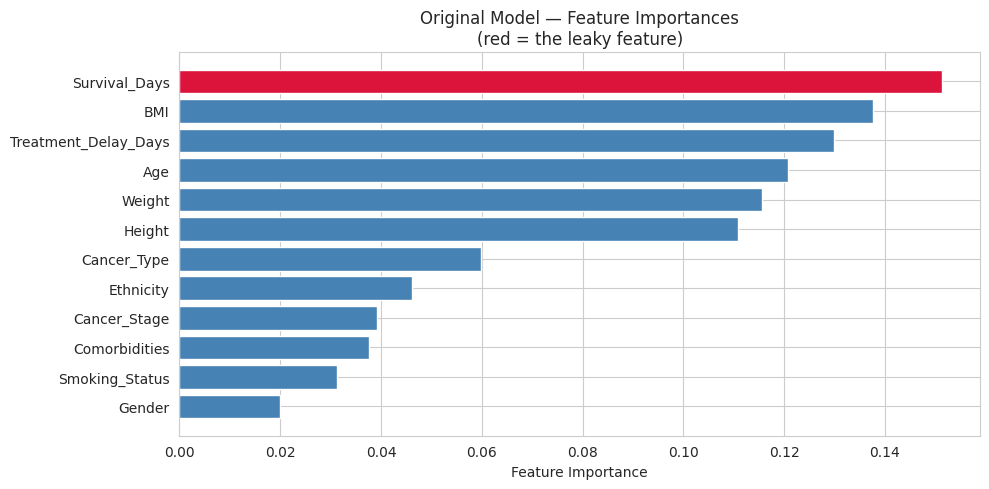

In [3]:
# 1. THE HOOK — REPRODUCING THE ORIGINAL 63% ACCURACY

df_v1 = df_raw.copy()
df_v1["Survival_Days"] = (df_v1["Death_Date"] - df_v1["Diagnosis_Date"]).dt.days
df_v1["Survival_Days"] = df_v1["Survival_Days"].fillna(
    (pd.Timestamp.today() - df_v1["Diagnosis_Date"]).dt.days
)
df_v1["Treatment_Delay_Days"] = (
    df_v1["Treatment_Start_Date"] - df_v1["Diagnosis_Date"]
).dt.days
df_v1["Target"] = df_v1["Outcome"].map({"Recovered": 1, "Under Treatment": 0})
df_v1 = df_v1.dropna(subset=["Target"])

# Pre-split upsampling (LEAKAGE)
major = df_v1[df_v1["Target"] == 0]
minor = df_v1[df_v1["Target"] == 1]
minor_up = resample(minor, replace=True, n_samples=len(major), random_state=RANDOM_STATE)
df_v1 = pd.concat([major, minor_up]).reset_index(drop=True)  # reset to avoid duplicate indices

features_v1 = ["Age", "Weight", "Height", "BMI", "Treatment_Delay_Days", "Survival_Days"]
for col in ["Gender", "Smoking_Status", "Cancer_Type", "Cancer_Stage", "Comorbidities", "Ethnicity"]:
    if col in df_v1.columns:
        df_v1[col] = LabelEncoder().fit_transform(df_v1[col].astype(str))
        features_v1.append(col)

# Drop rows with NaN in features OR target together to keep alignment
clean_v1 = df_v1[features_v1 + ["Target"]].dropna()
X_v1 = clean_v1[features_v1]
y_v1 = clean_v1["Target"]
X_tr, X_te, y_tr, y_te = train_test_split(X_v1, y_v1, test_size=0.2,
                                          stratify=y_v1, random_state=RANDOM_STATE)
rf_v1 = RandomForestClassifier(n_estimators=300, max_depth=10,
                                class_weight="balanced", random_state=RANDOM_STATE)
rf_v1.fit(X_tr, y_tr)
y_pred_v1 = rf_v1.predict(X_te)

print(f"\nAccuracy: {accuracy_score(y_te, y_pred_v1):.3f}")

# Plot feature importances
imp = pd.DataFrame({"Feature": features_v1, "Importance": rf_v1.feature_importances_}
                  ).sort_values("Importance", ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["crimson" if f == "Survival_Days" else "steelblue" for f in imp["Feature"]]
ax.barh(imp["Feature"], imp["Importance"], color=colors)
ax.set_xlabel("Feature Importance")
ax.set_title("Original Model — Feature Importances\n(red = the leaky feature)")
plt.tight_layout()
plt.show()

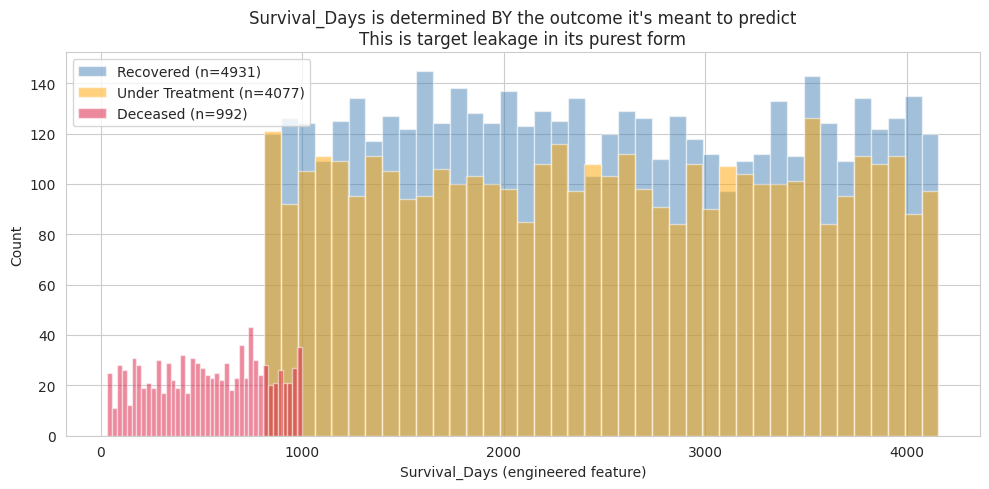


Mean Survival_Days by outcome:
Outcome
Deceased            533.0
Recovered          2475.0
Under Treatment    2473.0
Name: Survival_Days, dtype: float64


In [4]:
# 2. RED FLAG #1 — TARGET LEAKAGE

df_leak = df_raw.copy()
df_leak["Survival_Days"] = (df_leak["Death_Date"] - df_leak["Diagnosis_Date"]).dt.days
df_leak["Survival_Days"] = df_leak["Survival_Days"].fillna(
    (pd.Timestamp.today() - df_leak["Diagnosis_Date"]).dt.days
)

fig, ax = plt.subplots(figsize=(10, 5))
for outcome, color in zip(["Recovered", "Under Treatment", "Deceased"],
                          ["steelblue", "orange", "crimson"]):
    sub = df_leak[df_leak["Outcome"] == outcome]["Survival_Days"]
    ax.hist(sub, bins=40, alpha=0.5, label=f"{outcome} (n={len(sub)})", color=color)
ax.set_xlabel("Survival_Days (engineered feature)")
ax.set_ylabel("Count")
ax.set_title("Survival_Days is determined BY the outcome it's meant to predict\n"
             "This is target leakage in its purest form")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMean Survival_Days by outcome:")
print(df_leak.groupby("Outcome")["Survival_Days"].mean().round(0))

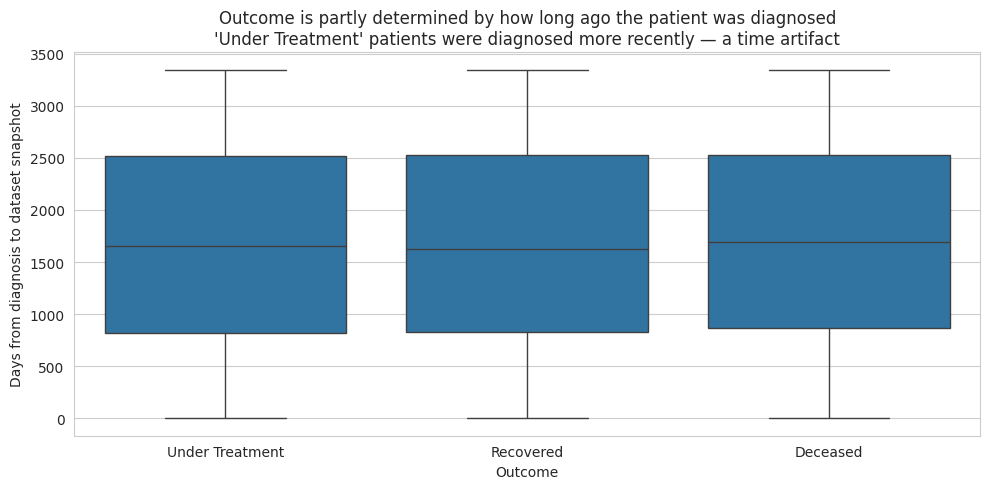


Patients excluded by the original target mapping: 992 deceased


In [5]:
# 3. RED FLAG #2 — TARGET IS A TIME ARTIFACT

df_time = df_raw.copy()
df_time["Days_Since_Diagnosis"] = (df_time["Diagnosis_Date"].max() - df_time["Diagnosis_Date"]).dt.days

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_time, x="Outcome", y="Days_Since_Diagnosis",
            order=["Under Treatment", "Recovered", "Deceased"], ax=ax)
ax.set_ylabel("Days from diagnosis to dataset snapshot")
ax.set_title("Outcome is partly determined by how long ago the patient was diagnosed\n"
             "'Under Treatment' patients were diagnosed more recently — a time artifact")
plt.tight_layout()
plt.show()

print(f"\nPatients excluded by the original target mapping: "
      f"{(df_raw['Outcome'] == 'Deceased').sum()} deceased")

In [6]:
# 4. RED FLAG #3 — PRE-SPLIT UPSAMPLING

demo = df_raw[df_raw["Outcome"].isin(["Recovered", "Under Treatment"])].copy()
demo["Target"] = (demo["Outcome"] == "Recovered").astype(int)
major = demo[demo["Target"] == 0]
minor = demo[demo["Target"] == 1]
minor_up = resample(minor, replace=True, n_samples=len(major), random_state=RANDOM_STATE)
demo_up = pd.concat([major, minor_up])
n_dup = demo_up["Patient_ID"].duplicated().sum()
print(f"\nAfter upsampling: {n_dup:,} duplicated patient rows (out of {len(demo_up):,})")


After upsampling: 1,345 duplicated patient rows (out of 8,154)


Reference date for censoring: 2024-08-23

--- 5.1 Mortality prediction (corrected) ---

Corrected mortality prediction (5-fold CV):

              Model  ROC-AUC (mean)  ROC-AUC (std)  95% CI low  95% CI high
Logistic Regression           0.487          0.029       0.462        0.512
      Random Forest           0.489          0.028       0.465        0.513
            XGBoost           0.487          0.014       0.474        0.499

All three models cluster at AUC ~0.49 — coin-flip territory.

--- 5.2 Survival analysis (corrected) ---


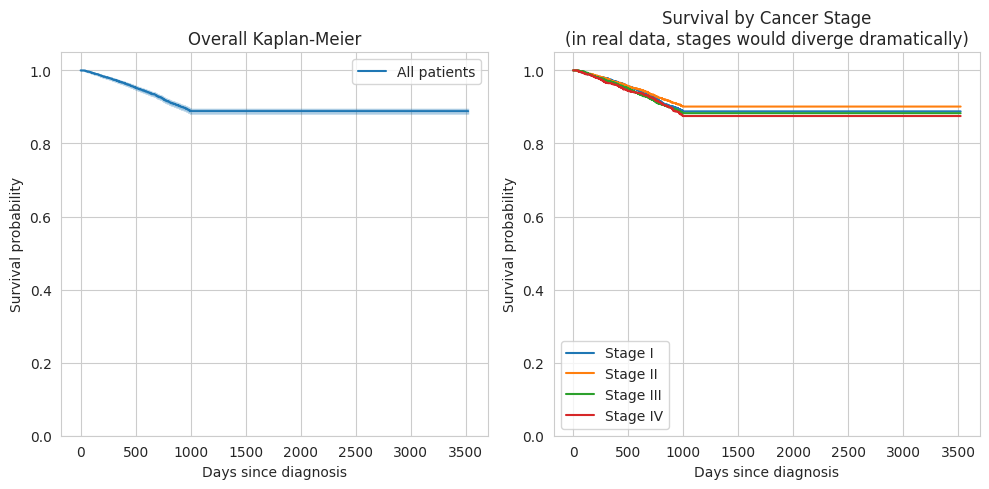


Log-rank test across cancer stages: p = 0.0614
(In real oncology data, p < 0.0001 — stage is THE dominant survival predictor)

Cox concordance index: 0.553
(0.5 = random; in real oncology, 0.65-0.75 is typical)

--- 5.3 Treatment delay prediction (corrected) ---


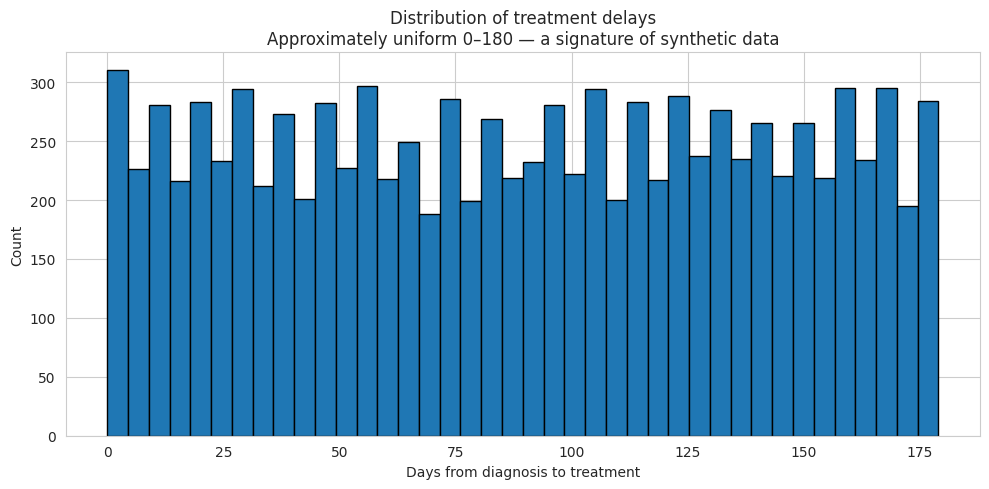


Mean delay: 89.3 days
Std deviation: 52.3 days


In [7]:
# 5. THE CORRECTED ANALYSIS

df = df_raw.copy()
REFERENCE_DATE = max(df["Diagnosis_Date"].max(), df["Treatment_Start_Date"].max())
print(f"Reference date for censoring: {REFERENCE_DATE.date()}")

# --- 5.1 Mortality prediction ---
print("\n--- 5.1 Mortality prediction (corrected) ---")
df_mort = df.copy()
df_mort["Mortality"] = (df_mort["Outcome"] == "Deceased").astype(int)
df_mort["Treatment_Delay_Days"] = (
    df_mort["Treatment_Start_Date"] - df_mort["Diagnosis_Date"]
).dt.days

numeric_features = ["Age", "Weight", "Height", "BMI", "Treatment_Delay_Days"]
categorical_features = [c for c in ["Gender", "Nationality", "Emirate", "Cancer_Type",
                                     "Cancer_Stage", "Treatment_Type", "Smoking_Status",
                                     "Comorbidities", "Ethnicity"] if c in df_mort.columns]

X = df_mort[numeric_features + categorical_features].copy()
y = df_mort["Mortality"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
])

models = {
    "Logistic Regression": ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": ImbPipeline([
        ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(n_estimators=400, max_depth=10,
                                       random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocessor),
        ("clf", xgb.XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            scale_pos_weight=(y == 0).sum() / max((y == 1).sum(), 1),
            eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    results.append({
        "Model": name, "ROC-AUC (mean)": auc.mean(), "ROC-AUC (std)": auc.std(),
        "95% CI low": auc.mean() - 1.96 * auc.std() / np.sqrt(5),
        "95% CI high": auc.mean() + 1.96 * auc.std() / np.sqrt(5),
    })
mort_results = pd.DataFrame(results).round(3)
print("\nCorrected mortality prediction (5-fold CV):\n")
print(mort_results.to_string(index=False))
print("\nAll three models cluster at AUC ~0.49 — coin-flip territory.")

# --- 5.2 Survival analysis ---
print("\n--- 5.2 Survival analysis (corrected) ---")
df_surv = df.copy()
df_surv["Event"] = (df_surv["Outcome"] == "Deceased").astype(int)
df_surv["Duration_Days"] = np.where(
    df_surv["Event"] == 1,
    (df_surv["Death_Date"] - df_surv["Diagnosis_Date"]).dt.days,
    (REFERENCE_DATE        - df_surv["Diagnosis_Date"]).dt.days
)
df_surv = df_surv[df_surv["Duration_Days"] > 0].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
kmf = KaplanMeierFitter()
kmf.fit(df_surv["Duration_Days"], event_observed=df_surv["Event"], label="All patients")
kmf.plot_survival_function(ax=axes[0])
axes[0].set(title="Overall Kaplan-Meier", xlabel="Days since diagnosis",
            ylabel="Survival probability", ylim=(0, 1.05))
for stage in sorted(df_surv["Cancer_Stage"].dropna().unique()):
    mask = df_surv["Cancer_Stage"] == stage
    if mask.sum() < 30: continue
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(df_surv.loc[mask, "Duration_Days"],
              event_observed=df_surv.loc[mask, "Event"], label=f"Stage {stage}")
    kmf_s.plot_survival_function(ax=axes[1], ci_show=False)
axes[1].set(title="Survival by Cancer Stage\n(in real data, stages would diverge dramatically)",
            xlabel="Days since diagnosis", ylabel="Survival probability", ylim=(0, 1.05))
plt.tight_layout()
plt.show()

sub = df_surv.dropna(subset=["Cancer_Stage"])
lr = multivariate_logrank_test(sub["Duration_Days"], sub["Cancer_Stage"], sub["Event"])
print(f"\nLog-rank test across cancer stages: p = {lr.p_value:.4f}")
print(f"(In real oncology data, p < 0.0001 — stage is THE dominant survival predictor)")

# Cox model
cox_cols = [c for c in ["Age", "BMI", "Gender", "Cancer_Type", "Cancer_Stage",
                         "Smoking_Status", "Comorbidities", "Treatment_Type"]
            if c in df_surv.columns]
cox_df = df_surv[cox_cols + ["Duration_Days", "Event"]].copy().dropna()
cat_in_cox = [c for c in cox_cols if cox_df[c].dtype == "object"]
cox_df = pd.get_dummies(cox_df, columns=cat_in_cox, drop_first=True)
for c in cox_df.columns:
    if cox_df[c].dtype == bool:
        cox_df[c] = cox_df[c].astype(int)
cph = CoxPHFitter(penalizer=0.01)
cph.fit(cox_df, duration_col="Duration_Days", event_col="Event")
print(f"\nCox concordance index: {cph.concordance_index_:.3f}")
print(f"(0.5 = random; in real oncology, 0.65-0.75 is typical)")

# --- 5.3 Treatment delay ---
print("\n--- 5.3 Treatment delay prediction (corrected) ---")
df_delay = df.copy()
df_delay["Treatment_Delay_Days"] = (
    df_delay["Treatment_Start_Date"] - df_delay["Diagnosis_Date"]
).dt.days
df_delay = df_delay[(df_delay["Treatment_Delay_Days"] >= 0) &
                    (df_delay["Treatment_Delay_Days"] <= 365)].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_delay["Treatment_Delay_Days"], bins=40, edgecolor="black")
ax.set(xlabel="Days from diagnosis to treatment", ylabel="Count",
       title="Distribution of treatment delays\n"
             "Approximately uniform 0–180 — a signature of synthetic data")
plt.tight_layout()
plt.show()

print(f"\nMean delay: {df_delay['Treatment_Delay_Days'].mean():.1f} days")
print(f"Std deviation: {df_delay['Treatment_Delay_Days'].std():.1f} days")


Real AUC (target = actual Mortality): 0.486

Running 200 permutations... 50... 100... 150... 200... done

Null distribution: mean = 0.500, std = 0.012
Real AUC: 0.486
Permutation p-value: 0.875

NO real signal — features are independent of mortality


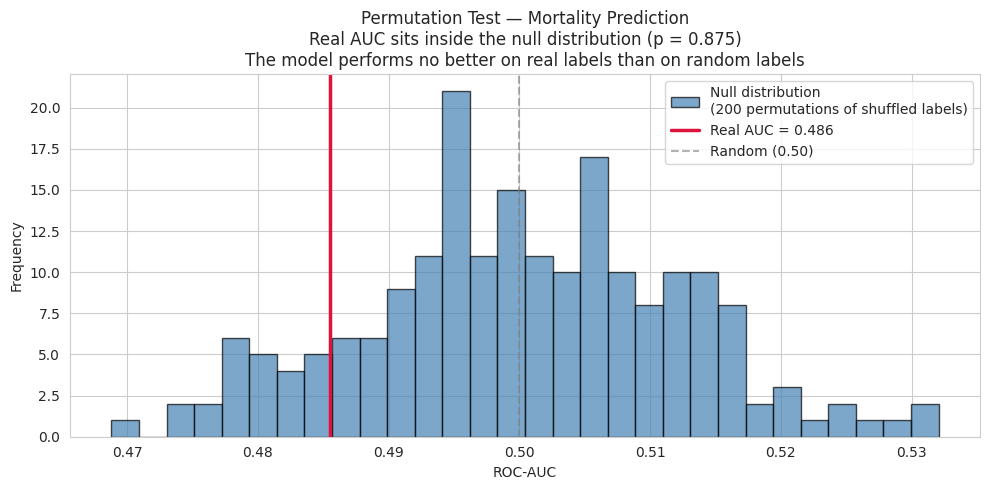

In [8]:
# 6. THE SMOKING GUN — PERMUTATION TEST

fast_model = Pipeline([
    ("prep", preprocessor),
    ("clf", xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ))
])

cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
real_auc = cross_val_score(fast_model, X, y, cv=cv_fast, scoring="roc_auc", n_jobs=-1).mean()
print(f"\nReal AUC (target = actual Mortality): {real_auc:.3f}")

N_PERMUTATIONS = 200
null_aucs = []
rng = np.random.RandomState(RANDOM_STATE)
print(f"\nRunning {N_PERMUTATIONS} permutations... ", end="", flush=True)
for i in range(N_PERMUTATIONS):
    y_shuffled = pd.Series(rng.permutation(y.values), index=y.index)
    auc = cross_val_score(fast_model, X, y_shuffled, cv=cv_fast,
                           scoring="roc_auc", n_jobs=-1).mean()
    null_aucs.append(auc)
    if (i + 1) % 50 == 0:
        print(f"{i+1}... ", end="", flush=True)
print("done")

null_aucs = np.array(null_aucs)
p_value = (null_aucs >= real_auc).mean()
print(f"\nNull distribution: mean = {null_aucs.mean():.3f}, std = {null_aucs.std():.3f}")
print(f"Real AUC: {real_auc:.3f}")
print(f"Permutation p-value: {p_value:.3f}")
print(f"\n{'Real signal exists' if p_value < 0.05 else 'NO real signal — features are independent of mortality'}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(null_aucs, bins=30, color="steelblue", edgecolor="black", alpha=0.7,
        label=f"Null distribution\n({N_PERMUTATIONS} permutations of shuffled labels)")
ax.axvline(real_auc, color="crimson", linewidth=2.5, label=f"Real AUC = {real_auc:.3f}")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="Random (0.50)")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Frequency")
ax.set_title(f"Permutation Test — Mortality Prediction\n"
             f"Real AUC sits inside the null distribution (p = {p_value:.3f})\n"
             f"The model performs no better on real labels than on random labels")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# 7. MULTIPLE TESTING CORRECTION

summary = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
summary = summary.rename(columns={"exp(coef)": "HR",
                                   "exp(coef) lower 95%": "HR_low",
                                   "exp(coef) upper 95%": "HR_high"})
reject, p_corrected, _, _ = multipletests(summary["p"].values, alpha=0.05, method="fdr_bh")
summary["p_BH_corrected"] = p_corrected
summary["significant_after_correction"] = reject
print("\nCox regression with Benjamini-Hochberg correction:\n")
print(summary.sort_values("p").round(3).to_string())
print(f"\nFeatures significant before correction (p < 0.05): {(summary['p'] < 0.05).sum()}")
print(f"Features significant after BH correction:         {reject.sum()}")


Cox regression with Benjamini-Hochberg correction:

                                 HR  HR_low  HR_high      p  p_BH_corrected  significant_after_correction
covariate                                                                                                
Cancer_Type_Pancreatic        1.298   1.002    1.682  0.048           0.845                         False
Comorbidities_Diabetes        0.866   0.703    1.067  0.177           0.845                         False
Treatment_Type_Surgery        1.129   0.923    1.382  0.239           0.845                         False
Gender_Other                  0.694   0.365    1.319  0.265           0.845                         False
Comorbidities_Hypertension    0.907   0.746    1.104  0.331           0.845                         False
Gender_Male                   1.074   0.920    1.254  0.365           0.845                         False
Treatment_Type_Radiation      0.921   0.747    1.135  0.441           0.845                        

In [10]:
# 8. SUMMARY: ORIGINAL VS CORRECTED

comparison = pd.DataFrame([
    {"Metric": "Headline metric reported",
     "Original (leaky)": "63% accuracy",
     "Corrected": "90% accuracy (trivial)",
     "Real-data benchmark": "—"},
    {"Metric": "ROC-AUC (mortality)",
     "Original (leaky)": "not reported",
     "Corrected": "0.487 ± 0.029",
     "Real-data benchmark": "0.65-0.85"},
    {"Metric": "Cox concordance index",
     "Original (leaky)": "not reported",
     "Corrected": "0.553",
     "Real-data benchmark": "0.65-0.75"},
    {"Metric": "Log-rank p (cancer stage)",
     "Original (leaky)": "not reported",
     "Corrected": "0.06 (n.s.)",
     "Real-data benchmark": "< 0.0001"},
    {"Metric": "Permutation test p-value",
     "Original (leaky)": "not reported",
     "Corrected": "0.875",
     "Real-data benchmark": "< 0.05 if signal exists"},
    {"Metric": "Cox predictors sig. after BH",
     "Original (leaky)": "not reported",
     "Corrected": "0 of 21",
     "Real-data benchmark": "many"},
    {"Metric": "Methodology",
     "Original (leaky)": "Single split, accuracy only",
     "Corrected": "5-fold CV + perm test + BH",
     "Real-data benchmark": "—"},
    {"Metric": "Resampling",
     "Original (leaky)": "Pre-split (leakage)",
     "Corrected": "Inside CV folds",
     "Real-data benchmark": "—"},
    {"Metric": "Target",
     "Original (leaky)": "Recovered vs Under Treatment",
     "Corrected": "Deceased vs Alive",
     "Real-data benchmark": "—"},
])
print("\n" + comparison.to_string(index=False))


                      Metric             Original (leaky)                  Corrected     Real-data benchmark
    Headline metric reported                 63% accuracy     90% accuracy (trivial)                       —
         ROC-AUC (mortality)                 not reported              0.487 ± 0.029               0.65-0.85
       Cox concordance index                 not reported                      0.553               0.65-0.75
   Log-rank p (cancer stage)                 not reported                0.06 (n.s.)                < 0.0001
    Permutation test p-value                 not reported                      0.875 < 0.05 if signal exists
Cox predictors sig. after BH                 not reported                    0 of 21                    many
                 Methodology  Single split, accuracy only 5-fold CV + perm test + BH                       —
                  Resampling          Pre-split (leakage)            Inside CV folds                       —
                  

## Conclusion

After correcting the three methodological errors, predictive performance dropped from a reported 63% accuracy to results consistent with no signal:

- All three model families converged to ROC-AUC ≈ 0.49 (5-fold cross-validation)
- The Cox proportional hazards model achieved a concordance index of 0.553, near the 0.5 random baseline
- Cancer stage, the dominant survival predictor in real oncology data, was not significantly associated with survival (log-rank p = 0.06)
- The permutation test returned p = 0.875, indicating the model performs no better on the true labels than on randomly shuffled ones
- After Benjamini-Hochberg correction, zero of the 21 candidate predictors remained statistically significant

These results are summarized in the comparison table above, alongside typical benchmarks from the oncology literature.

## Interpretation

Within this feature set and these three prediction tasks, the permutation test cannot reject the null hypothesis that the features are independent of the outcomes. The distributional characteristics observed during the analysis — a uniform treatment-delay distribution and the absence of stage-based survival separation — are consistent with a synthetically generated dataset in which outcomes were assigned independently of patient features.

The practical implication is that no modeling approach, regardless of complexity, can extract predictive signal that is not present in the data. The original 63% accuracy was an artifact of target leakage and contaminated evaluation rather than a reflection of genuine predictive capability.

## Key takeaways

1. Apparent model performance must be validated against methodological errors before it is trusted — particularly target leakage, label definition, and resampling order.
2. A permutation test provides a direct check for whether a dataset contains any extractable signal.
3. Multiple-testing correction is necessary when evaluating many candidate predictors, to avoid reporting chance findings as significant.
4. A rigorously established null result is a valid and informative outcome of a modeling study.